In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_pickle("dataframe/fidelity_statistic_results_unitary.pkl")

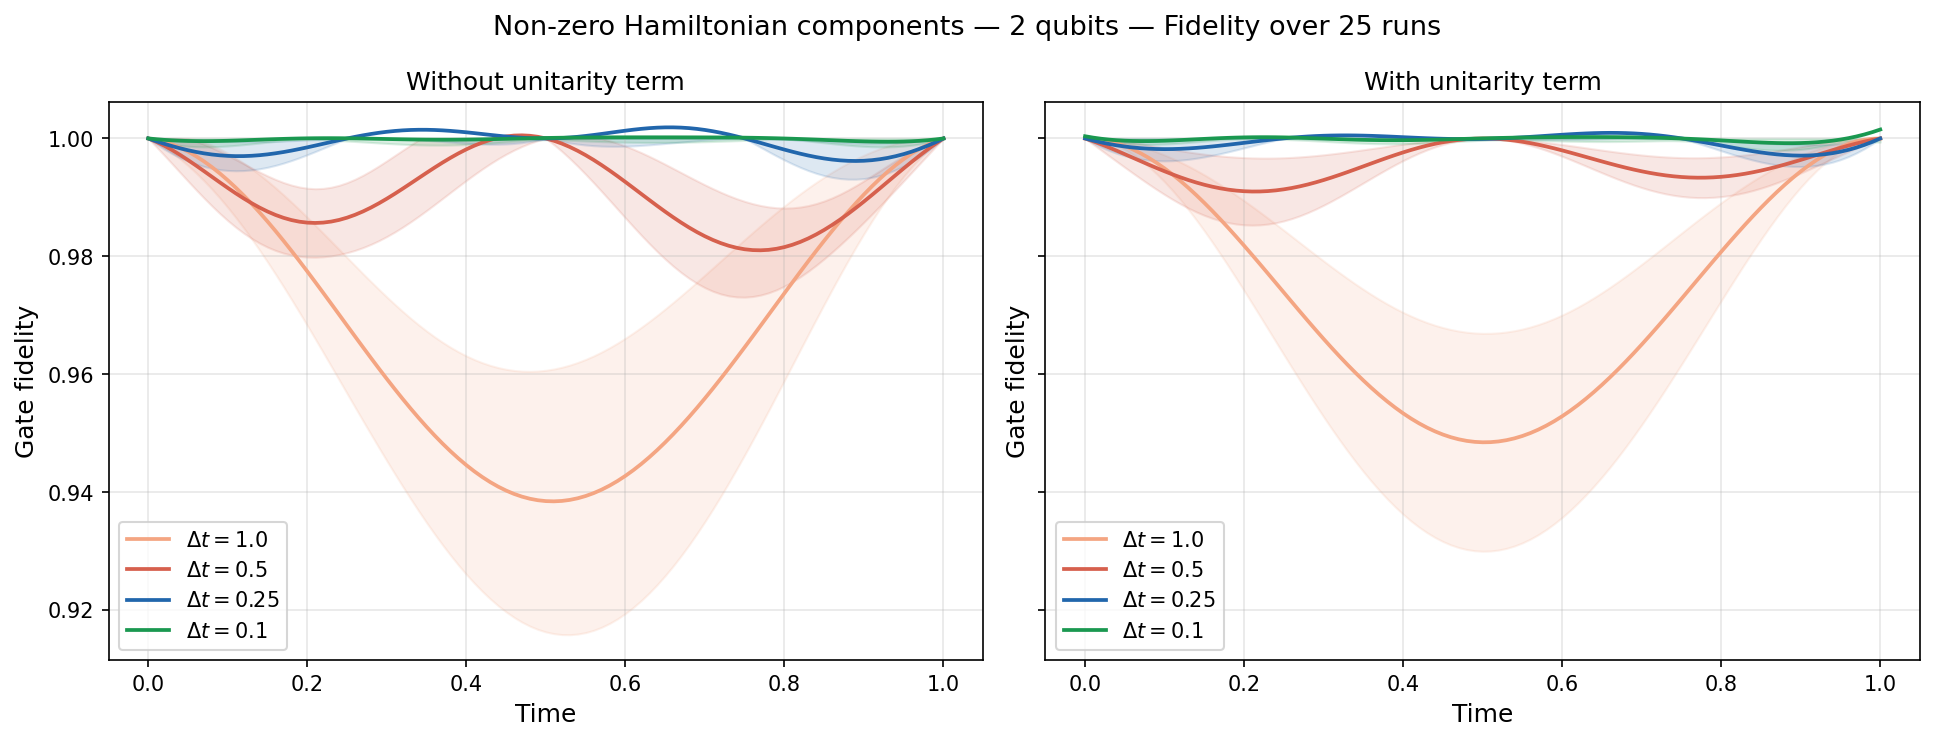

Figure saved: figures/fidelity_unitarity_N2.pdf


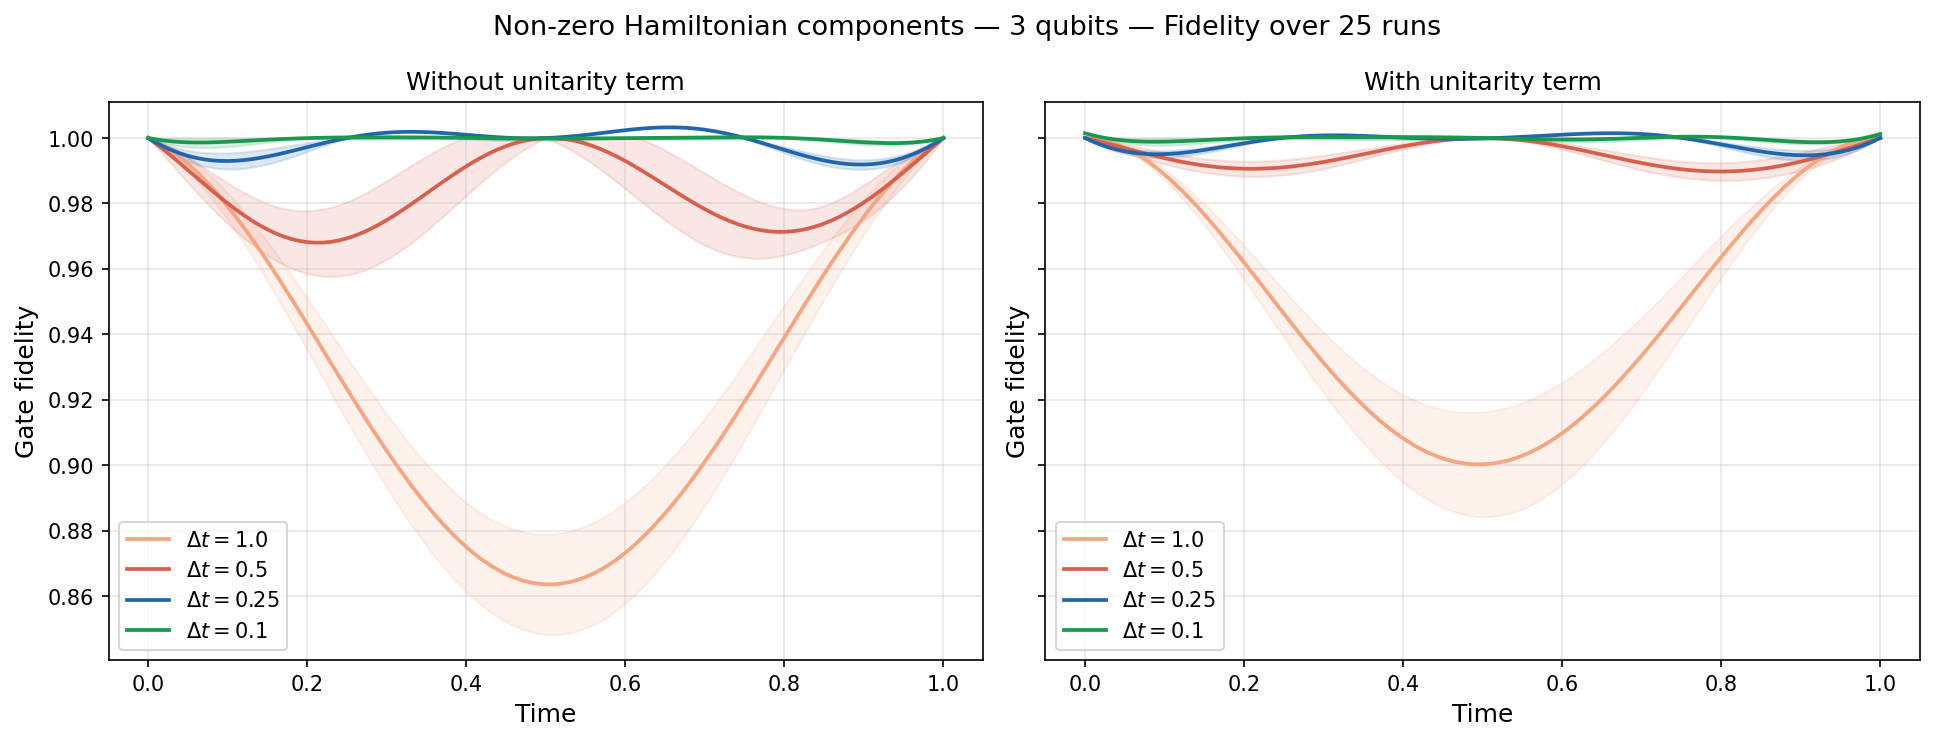

Figure saved: figures/fidelity_unitarity_N3.pdf


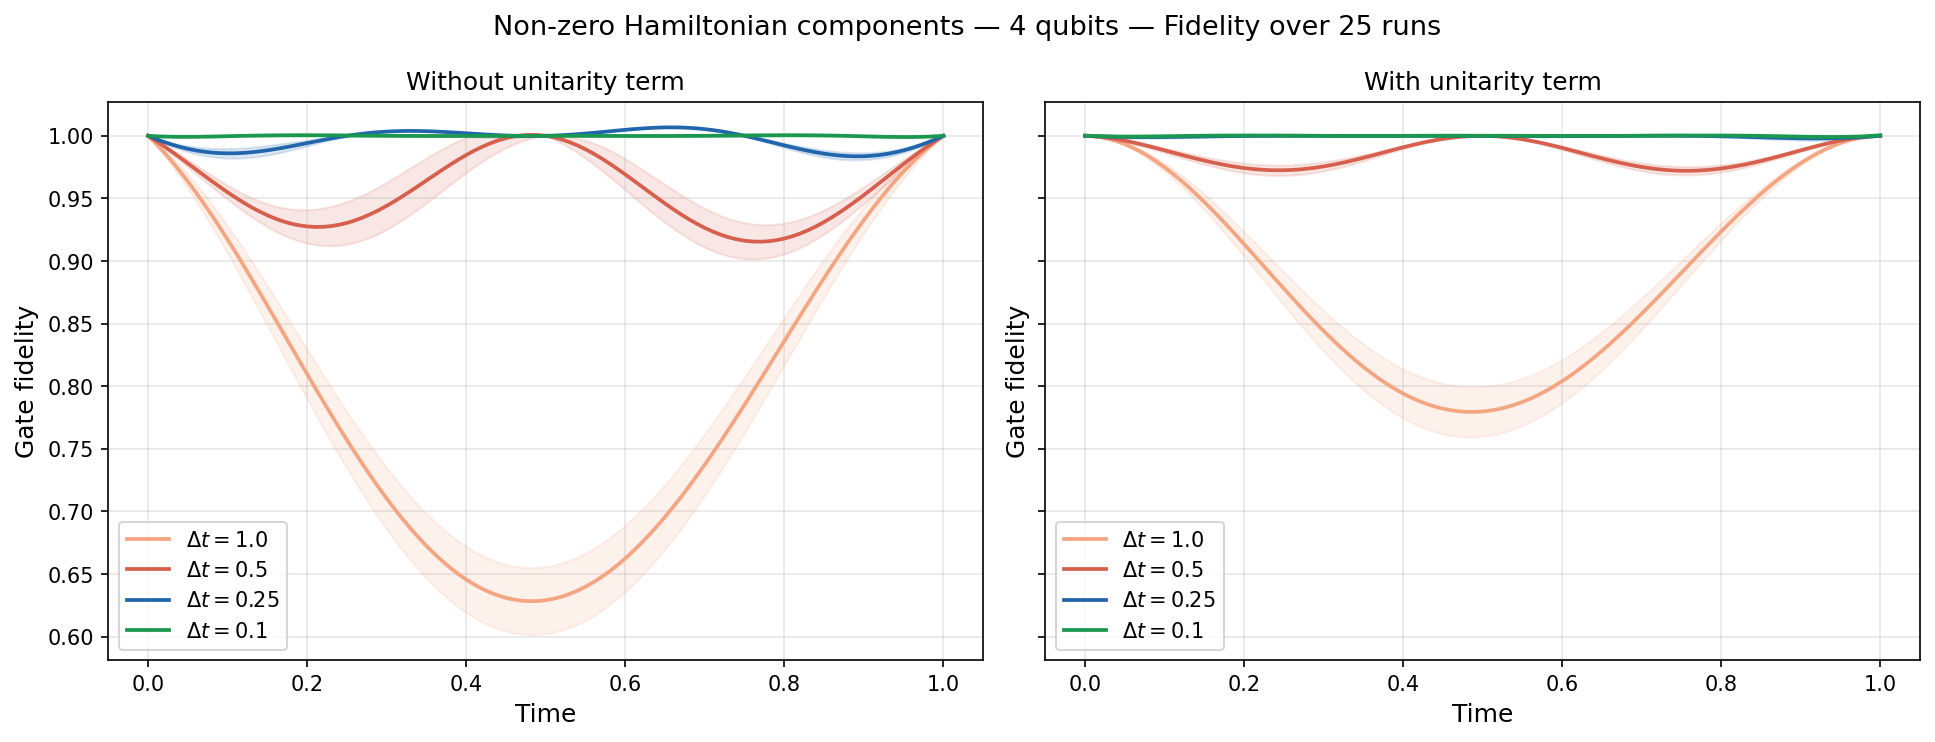

Figure saved: figures/fidelity_unitarity_N4.pdf


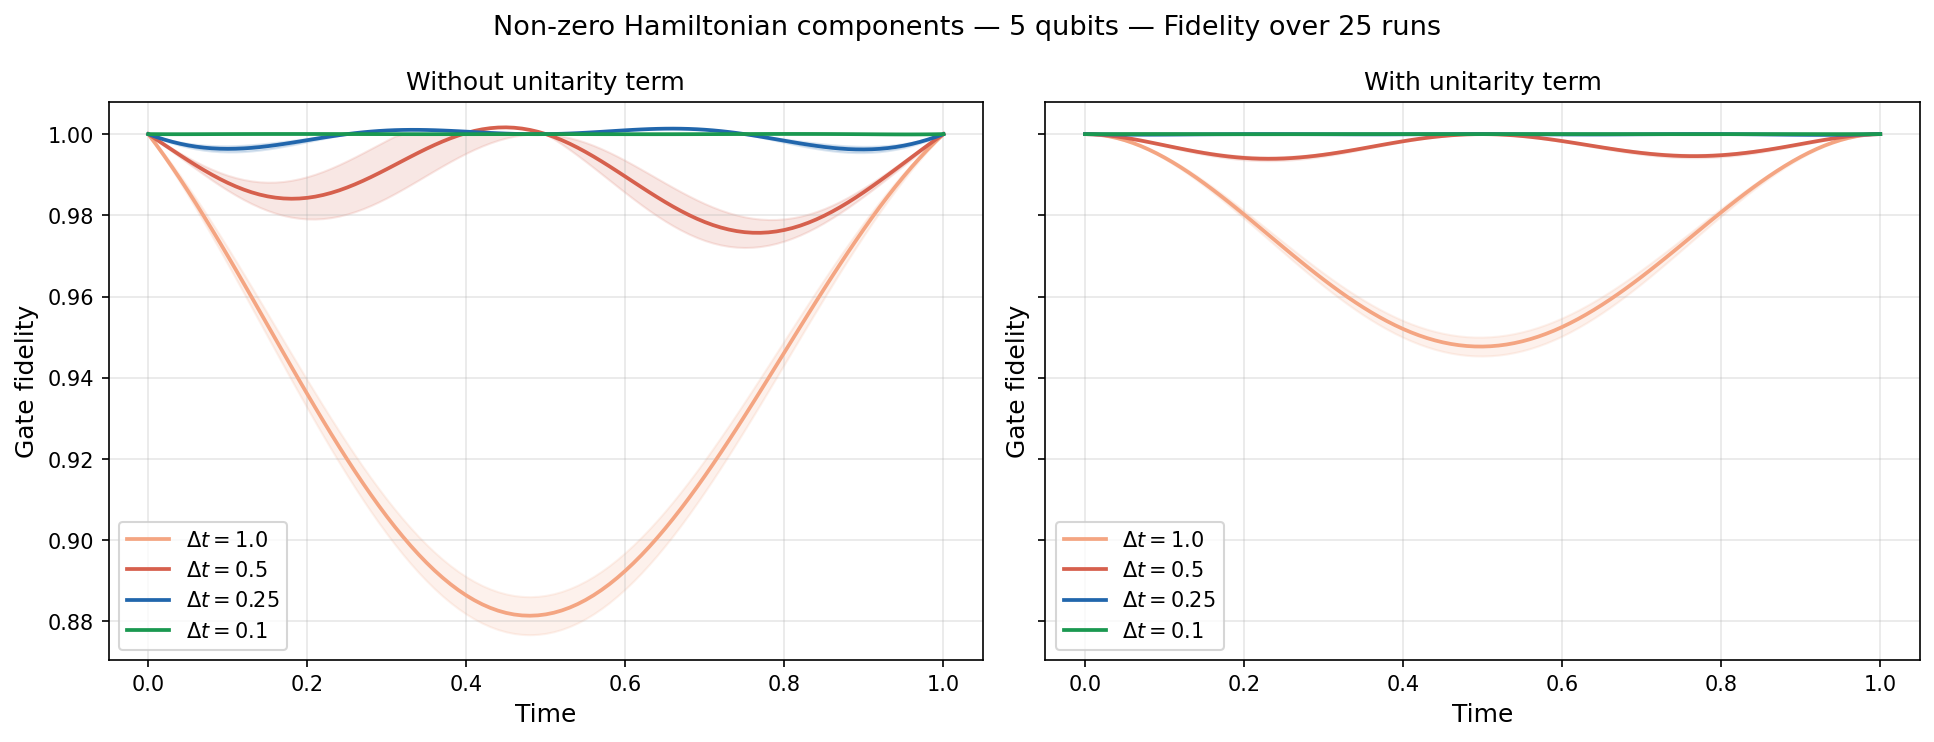

Figure saved: figures/fidelity_unitarity_N5.pdf


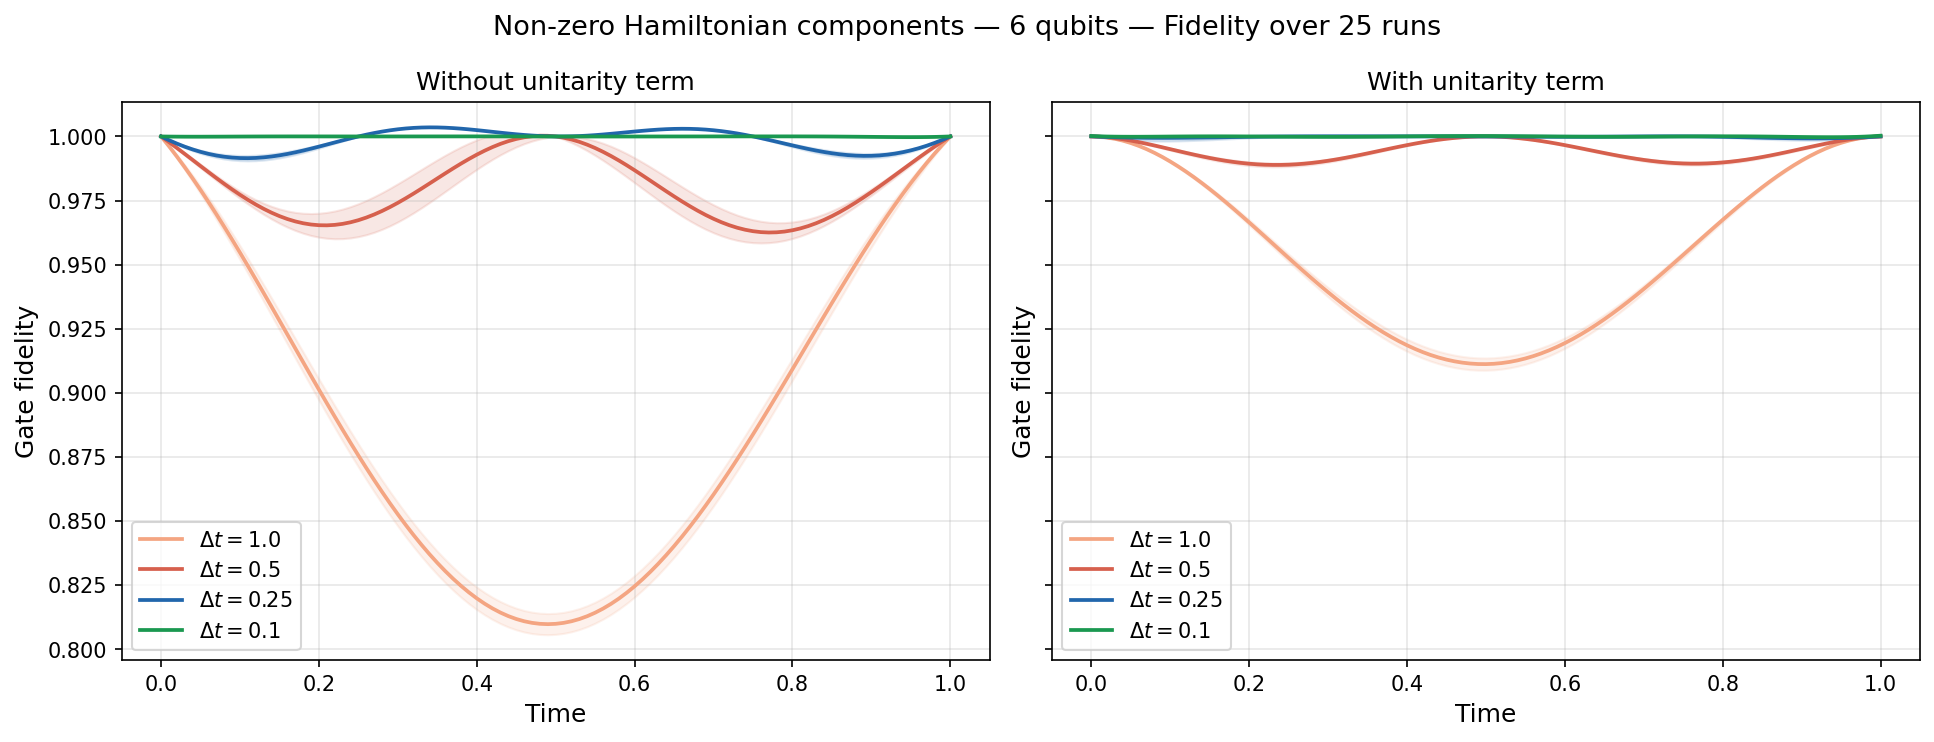

Figure saved: figures/fidelity_unitarity_N6.pdf


In [3]:
time_test = np.linspace(0, 1, 101)  # 100 puntos, excluye t=0

colors_dt = {
    1.00: "#f4a582",
    0.50: "#d6604d",
    0.25: "#2166ac",
    0.10: "#1a9850"
}
dt_labels = {
    1.00: r"$\Delta t = 1.0$",
    0.50: r"$\Delta t = 0.5$",
    0.25: r"$\Delta t = 0.25$",
    0.10: r"$\Delta t = 0.1$"
}

for N in [2, 3, 4, 5, 6]:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150, sharey=True)

    for col, unitarity in enumerate([False, True]):
        ax    = axes[col]
        title = "With unitarity term" if unitarity else "Without unitarity term"

        df_sub = df[(df["N"] == N) & (df["Unitarity"] == unitarity)]

        for dt in [1.00, 0.50, 0.25, 0.10]:
            df_dt = df_sub[np.isclose(df_sub["delta_t"], dt)]
            if df_dt.empty:
                continue

            # Stack fidelity arrays: shape (n_runs, n_time)
            F_matrix = np.stack(df_dt["F"].values)

            mean = F_matrix.mean(axis=0)
            std  = F_matrix.std(axis=0)

            upper = np.clip(mean + std, 0, 1)
            lower = np.clip(mean - std, 0, 1)

            ax.plot(
                time_test, mean,
                color=colors_dt[dt], label=dt_labels[dt], lw=1.8
            )
            ax.fill_between(
                time_test, lower, upper,
                color=colors_dt[dt], alpha=0.15
            )

        ax.set_xlabel("Time", fontsize=12)
        ax.set_ylabel("Gate fidelity", fontsize=12)
        ax.set_title(title, fontsize=12)
        # ax.set_ylim([0.85, 1.005])
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)

    fig.suptitle(
        f"Non-zero Hamiltonian components — {N} qubits — Fidelity over 25 runs",
        fontsize=13
    )
    plt.tight_layout()
    plt.savefig(f"figures/fidelity_unitarity_N{N}.pdf", bbox_inches="tight")
    plt.show()
    print(f"Figure saved: figures/fidelity_unitarity_N{N}.pdf")